# Unemployment Analysis with Python
CodeAlpha Task 2

In [1]:

%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:

df = pd.read_csv('Unemployment.csv')
print('Shape:', df.shape)
df.head()


Shape: (768, 7)


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [3]:

df.columns = df.columns.str.strip()
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

print(df.info())
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   Region                                   740 non-null    object        
 1   Date                                     740 non-null    datetime64[ns]
 2   Frequency                                740 non-null    object        
 3   Estimated Unemployment Rate (%)          740 non-null    float64       
 4   Estimated Employed                       740 non-null    float64       
 5   Estimated Labour Participation Rate (%)  740 non-null    float64       
 6   Area                                     740 non-null    object        
dtypes: datetime64[ns](1), float64(3), object(3)
memory usage: 42.1+ KB
None


,Date,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740,740.000000,7.400000e+02,740.000000
mean,2019-12-12 18:36:58.378378496,11.787946,7.204460e+06,42.630122
min,2019-05-31 00:00:00,0.000000,4.942000e+04,13.330000
25%,2019-08-31 00:00:00,4.657500,1.190404e+06,38.062500
50%,2019-11-30 00:00:00,8.350000,4.744178e+06,41.160000
75%,2020-03-31 00:00:00,15.887500,1.127549e+07,45.505000
max,2020-06-30 00:00:00,76.740000,4.577751e+07,72.570000
std,NaN,10.721298,8.087988e+06,8.111094


In [4]:

print('Missing Values:')
print(df.isnull().sum())


Missing Values:
Region                                     28
Date                                       28
Frequency                                  28
Estimated Unemployment Rate (%)            28
Estimated Employed                         28
Estimated Labour Participation Rate (%)    28
Area                                       28
dtype: int64


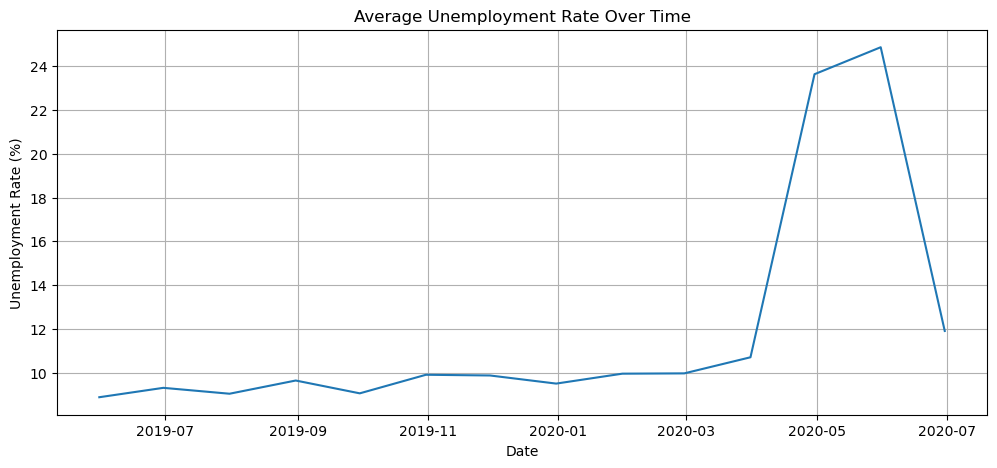

In [5]:

avg_unemployment = df.groupby('Date')['Estimated Unemployment Rate (%)'].mean().reset_index()

plt.figure(figsize=(12,5))
plt.plot(avg_unemployment['Date'], avg_unemployment['Estimated Unemployment Rate (%)'])
plt.title('Average Unemployment Rate Over Time')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.grid(True)
plt.show()


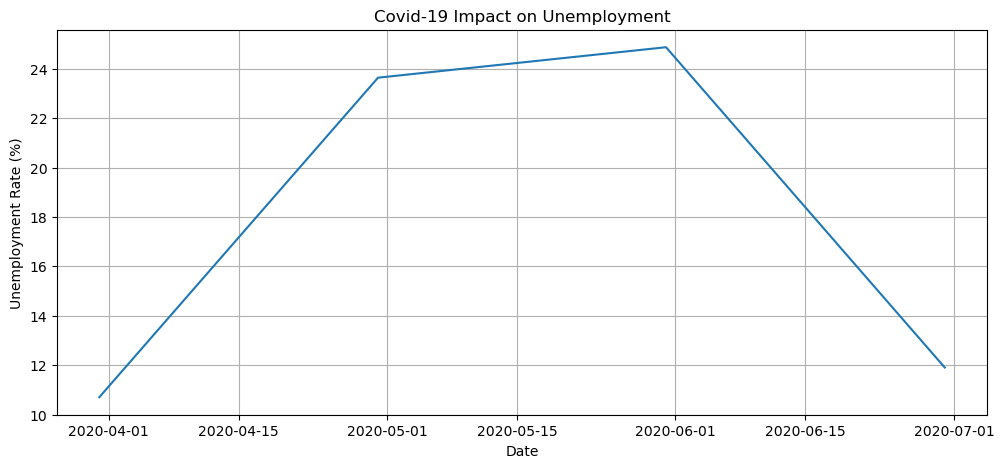

In [6]:

covid_period = df[df['Date'] >= '2020-03-01']

covid_avg = covid_period.groupby('Date')['Estimated Unemployment Rate (%)'].mean().reset_index()

plt.figure(figsize=(12,5))
plt.plot(covid_avg['Date'], covid_avg['Estimated Unemployment Rate (%)'])
plt.title('Covid-19 Impact on Unemployment')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.grid(True)
plt.show()


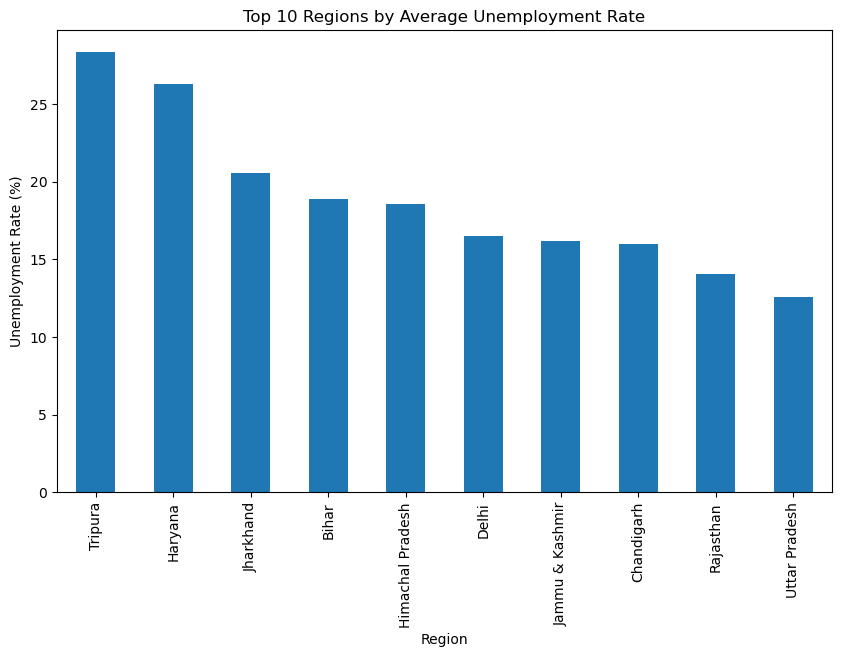

In [7]:

top_states = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
top_states.plot(kind='bar')
plt.title('Top 10 Regions by Average Unemployment Rate')
plt.ylabel('Unemployment Rate (%)')
plt.show()


In [9]:
print(df.columns.tolist())

['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Area']


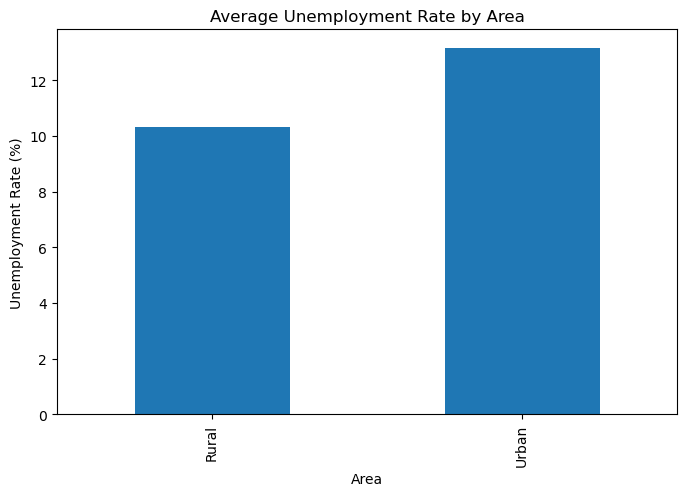

In [11]:
region_rates = df.groupby('Area')['Estimated Unemployment Rate (%)'].mean()

plt.figure(figsize=(8,5))
region_rates.plot(kind='bar')

plt.title('Average Unemployment Rate by Area')
plt.ylabel('Unemployment Rate (%)')
plt.xlabel('Area')

plt.show()

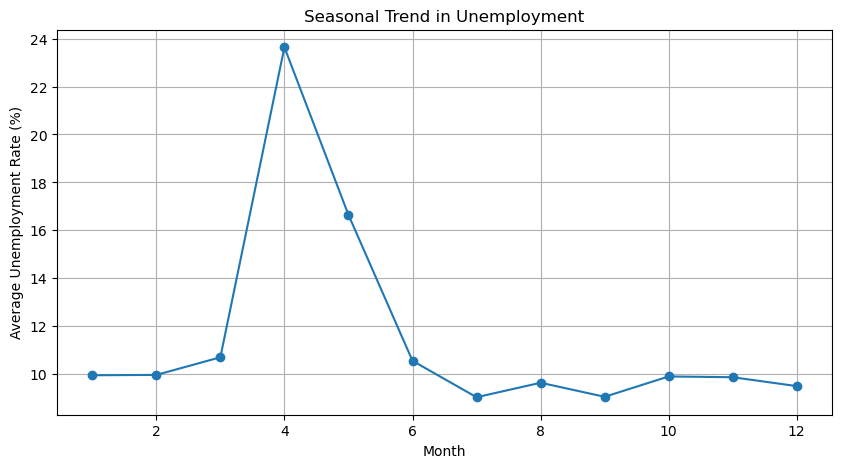

In [12]:

monthly = df.groupby(df['Date'].dt.month)['Estimated Unemployment Rate (%)'].mean()

plt.figure(figsize=(10,5))
monthly.plot(marker='o')
plt.title('Seasonal Trend in Unemployment')
plt.xlabel('Month')
plt.ylabel('Average Unemployment Rate (%)')
plt.grid(True)
plt.show()


In [13]:

peak = df.loc[df['Estimated Unemployment Rate (%)'].idxmax()]

print('Highest Unemployment Record')
print(peak[['Region','Date','Estimated Unemployment Rate (%)']])


Highest Unemployment Record
Region                                      Puducherry
Date                               2020-04-30 00:00:00
Estimated Unemployment Rate (%)                  76.74
Name: 627, dtype: object


In [14]:

insights = [
'Covid-19 period shows a significant rise in unemployment levels.',
'Some states consistently report higher unemployment than others.',
'Seasonal variations indicate labour market fluctuations throughout the year.',
'Regions with high unemployment may require targeted employment schemes.',
'Government policies can focus on skill development and job creation in high-risk areas.'
]

for i in insights:
    print('-', i)


- Covid-19 period shows a significant rise in unemployment levels.
- Some states consistently report higher unemployment than others.
- Seasonal variations indicate labour market fluctuations throughout the year.
- Regions with high unemployment may require targeted employment schemes.
- Government policies can focus on skill development and job creation in high-risk areas.
